In [1]:
import numpy as np
from scipy.special import jn, jn_zeros
import matplotlib.pyplot as plt

def compute_a_nm_vectorized(f, R, N=5, M=5, Nr=200, Ntheta=360):
    """
    Vectorized computation of Fourier-Bessel coefficients a_nm for a 2D function f(r,theta)
    """
    # sample points
    r = np.linspace(0, R, Nr)
    theta = np.linspace(0, 2*np.pi, Ntheta)
    dr = R / (Nr-1)
    dtheta = 2*np.pi / Ntheta
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_vals = f(rr, tt, R)  # shape (Nr, Ntheta)

    # prepare output
    a_nm = np.zeros((N, M), dtype=complex)

    for n in range(N):
        alpha_nm = jn_zeros(n, M)  # zeros of J_n
        k_nm = alpha_nm / R        # radial wave numbers

        # Precompute all radial Bessel functions at once: shape (Nr, M)
        J_vals = jn(n, np.outer(r, k_nm))  # rr[:, None] * k_nm[None, :]

        # Precompute angular exponentials: shape (Ntheta,)
        exp_n_theta = np.exp(-1j * n * theta)  # shape (Ntheta,)

        # Compute integral using matrix multiplication
        # f_vals: (Nr, Ntheta), J_vals: (Nr,M), exp_n_theta: (Ntheta,)
        # Step 1: multiply by angular factor
        f_theta = f_vals * exp_n_theta[None, :]  # shape (Nr, Ntheta)
        # Step 2: integrate over theta
        int_theta = np.sum(f_theta, axis=1) * dtheta  # shape (Nr,)
        # Step 3: multiply by radial Bessels and r dr
        # int_theta[:, None] * J_vals * r[:, None] -> shape (Nr,M)
        integrand = int_theta[:, None] * J_vals * r[:, None]
        integral = np.sum(integrand, axis=0) * dr  # shape (M,)

        # Normalization
        norm = (R**2 / 2) * (jn(n+1, alpha_nm)**2)
        a_nm[n, :] = integral / norm

    return a_nm

def recon_from_a_nm_vectorized(a_nm, R, r, theta):
    """
    Vectorized reconstruction from Fourier-Bessel coefficients
    """
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_recon = np.zeros_like(rr, dtype=complex)

    N, M = a_nm.shape

    for n in range(N):
        alpha_nm = jn_zeros(n, M)
        k_nm = alpha_nm / R
        # shape (Nr,M)
        J_vals = jn(n, np.outer(r, k_nm))
        # shape (Ntheta,)
        exp_n_theta = np.exp(1j * n * theta)
        # reconstruction using broadcasting
        # rr[:,None] * k_nm[None,:] already handled in J_vals
        # sum over m
        f_n = J_vals @ a_nm[n, :]  # shape (Nr,)
        f_recon += f_n[:, None] * exp_n_theta[None, :]  # shape (Nr,Ntheta)

    return f_recon


In [2]:
%matplotlib widget

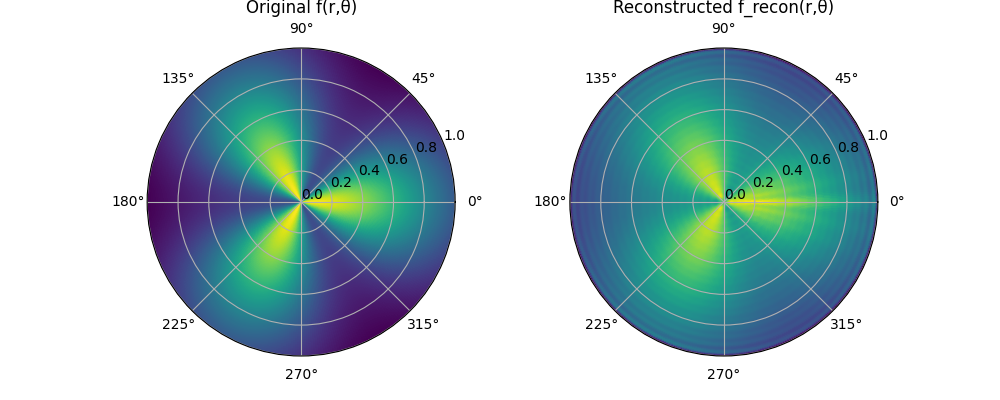

In [3]:

def f_mixed(r, theta, R):
    return np.exp(-(r/R)**2) * (1 + 0.5*np.cos(3*theta))

# parameters
R = 1.0
N, M = 40, 40
Nr, Ntheta = 400, 400
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)

# compute coefficients and reconstruction
a_nm = compute_a_nm_vectorized(f_mixed, R, N, M, Nr, Ntheta)
f_recon = recon_from_a_nm_vectorized(a_nm, R, r, theta)

# original for comparison
rr, tt = np.meshgrid(r, theta, indexing='ij')
f_true = f_mixed(rr, tt, R)

# plot real parts
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})
ax[0].pcolormesh(tt, rr, np.real(f_true), shading='auto')
ax[0].set_title("Original f(r,θ)")
ax[1].pcolormesh(tt, rr, np.real(f_recon), shading='auto')
ax[1].set_title("Reconstructed f_recon(r,θ)")
plt.show()


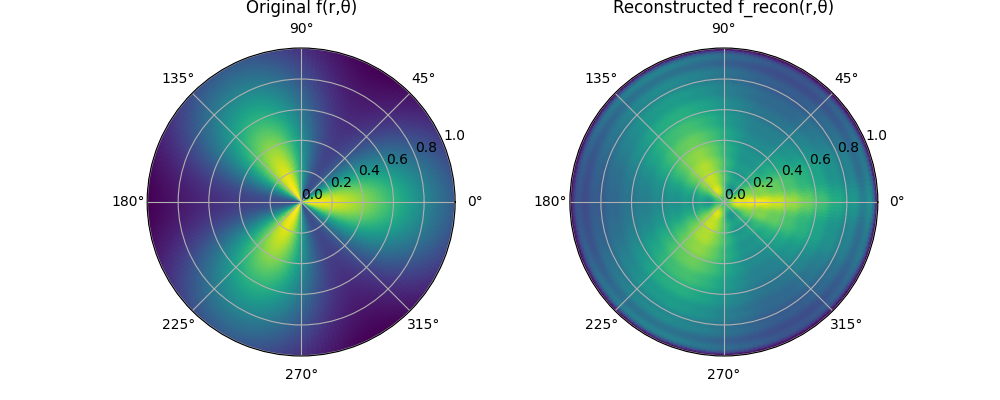

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from scipy.special import jn, jn_zeros

# -------------------------
# Example function
# -------------------------
def test_func(r, theta, R):
    return np.exp(-(r/R)**2) * (1 + 0.5*np.cos(3*theta))
# -------------------------
# Parameters
# -------------------------
R = 1.0
N_max, M_max = 20, 20
Nr, Ntheta = 200, 200

r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
rr, tt = np.meshgrid(r, theta, indexing='ij')
f_true = test_func(rr, tt, R)

# -------------------------
# Vectorized coefficient computation
# -------------------------
def compute_a_nm_vectorized(f, R, N=20, M=20, Nr=200, Ntheta=200):
    r = np.linspace(0, R, Nr)
    theta = np.linspace(0, 2*np.pi, Ntheta)
    dr = R / (Nr-1)
    dtheta = 2*np.pi / Ntheta
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_vals = f(rr, tt, R)
    
    a_nm = np.zeros((N, M), dtype=complex)
    J_vals_all = np.zeros((N, M, Nr))
    exp_n_theta = np.zeros((N, Ntheta), dtype=complex)
    
    for n in range(N):
        alpha_nm = jn_zeros(n, M)
        k_nm = alpha_nm / R
        J_vals_all[n,:,:] = jn(n, np.outer(r, k_nm)).T
        exp_n_theta[n,:] = np.exp(-1j * n * theta)
        
        for m_idx, alpha in enumerate(alpha_nm):
            basis = J_vals_all[n, m_idx, :][:, None] * exp_n_theta[n,:][None, :]
            integrand = f_vals * np.conj(basis) * rr
            integral = np.sum(integrand) * dr * dtheta
            norm = (R**2 / 2) * (jn(n+1, alpha)**2)
            a_nm[n,m_idx] = integral / norm
    return a_nm, J_vals_all, exp_n_theta

# Precompute
a_nm, J_vals_all, exp_n_theta = compute_a_nm_vectorized(test_func, R, N_max, M_max, Nr, Ntheta)

# -------------------------
# Incremental reconstruction
# -------------------------
def recon_partial(n_max, m_max):
    f_recon = np.zeros((Nr, Ntheta), dtype=complex)
    for n in range(n_max+1):
        J_slice = J_vals_all[n,:m_max+1,:]  # shape (m_max+1, Nr)
        a_slice = a_nm[n,:m_max+1]          # shape (m_max+1,)
        f_r = (J_slice.T @ a_slice)         # shape (Nr,)
        f_recon += f_r[:, None] * np.exp(1j*n*theta)[None,:]
    return f_recon


f_recon= recon_partial(N_max-1, M_max-1)

# plot real parts
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})
ax[0].pcolormesh(tt, rr, np.real(f_true), shading='auto')
ax[0].set_title("Original f(r,θ)")
ax[1].pcolormesh(tt, rr, np.real(f_recon), shading='auto')
ax[1].set_title("Reconstructed f_recon(r,θ)")
plt.show()


interactive(children=(IntSlider(value=0, description='n_max', max=19), IntSlider(value=0, description='m_max',…

<function __main__.update(n_max=0, m_max=0)>

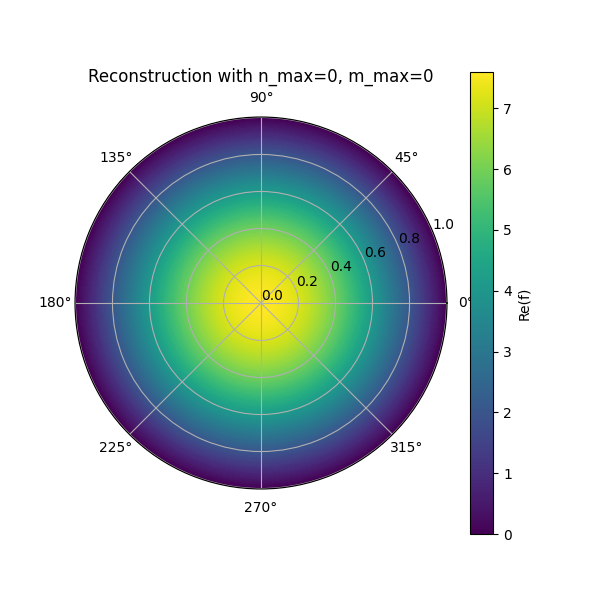

In [5]:
plt.close()

# -------------------------
# Polar plot setup
# -------------------------
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
c = ax.pcolormesh(tt, rr, np.real(f_true), shading='auto', cmap='viridis')
ax.set_title("Fourier-Bessel Reconstruction (Polar)")
fig.colorbar(c, ax=ax, label='Re(f)')

# -------------------------
# Slider update function
# -------------------------
def update(n_max=0, m_max=0):
    f_recon = recon_partial(n_max, m_max)
    # Use magnitude to avoid negative/oscillation extremes
    data_to_plot = np.abs(f_recon)
    c.set_array(data_to_plot.ravel())
    # Update color limits dynamically
    c.set_clim(0, np.max(data_to_plot))
    ax.set_title(f'Reconstruction with n_max={n_max}, m_max={m_max}')
    fig.canvas.draw_idle()

interact(update,
         n_max=IntSlider(min=0,max=N_max-1,value=0, description='n_max'),
         m_max=IntSlider(min=0,max=M_max-1,value=0, description='m_max'))